# １章３節７項 アンビギュイティ

## 概要
アンビギュイティの説明のための相関処理。
周期的な類似が発生することイメージを捉える

## 使用データ
なし

In [ ]:
import os
import numpy as np
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

PATH_OUTPUT = os.path.join('output', '1_3_7')
os.makedirs(PATH_OUTPUT, exist_ok=True)

In [2]:
# chirp信号の生成
def phase_(t, f0, f_doppler):
    return 2 * np.pi * (f0 * t + 0.5 * f_doppler * t ** 2)

def chirp_(t, f0, f_doppler):
    return np.exp(1j * phase_(t, f0, f_doppler))

def impulse_response(reserve, reference):
    return np.fft.ifftshift(np.fft.ifft(np.fft.fft(reserve) * np.conj(np.fft.fft(reference))))

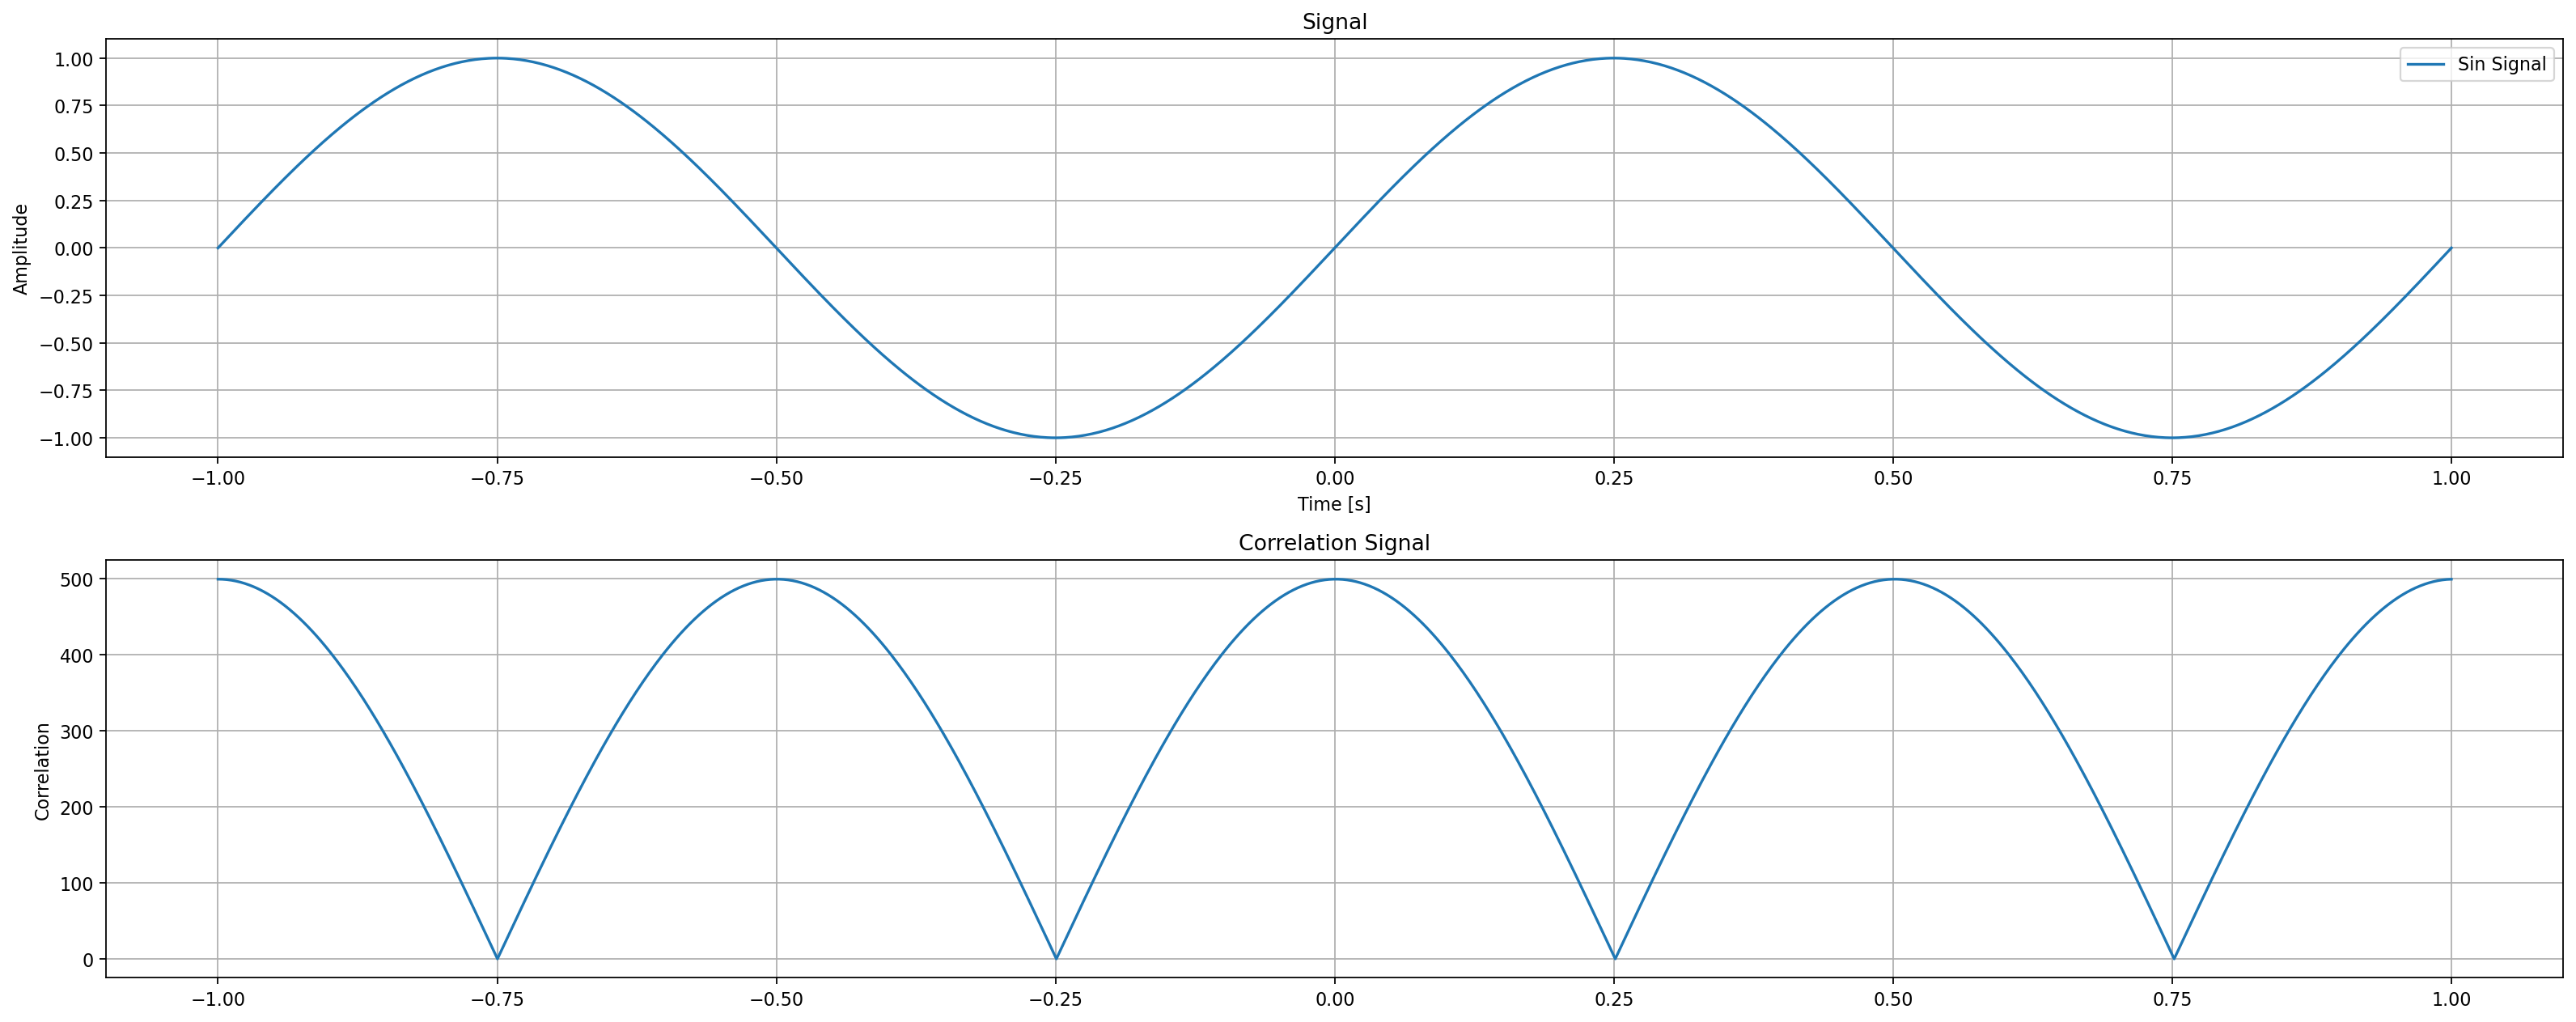

In [14]:
NUM_SAMPLE = 1000
FREQ_CENTER = 2
FREQ_DOPPLER = 0

t_sample = np.linspace(-1, 1, NUM_SAMPLE)
signal = chirp_(t_sample, FREQ_CENTER, FREQ_DOPPLER)
signal_sin = np.sin(2 * np.pi * t_sample)

# plot
plt.figure(figsize=(20, 8), facecolor='w', edgecolor='k', dpi=160)
plt.subplot(2, 1, 1)
plt.plot(t_sample, np.real(signal_sin), label='Sin Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.title('Signal')

correlation = impulse_response(signal_sin, signal_sin)

plt.subplot(2, 1, 2)
plt.plot(t_sample, np.abs(correlation))
plt.xlabel('')
plt.ylabel('Correlation')
plt.grid()
plt.title('Correlation Signal')

plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'correlation_signal.png'))
plt.show();plt.clf();plt.close();

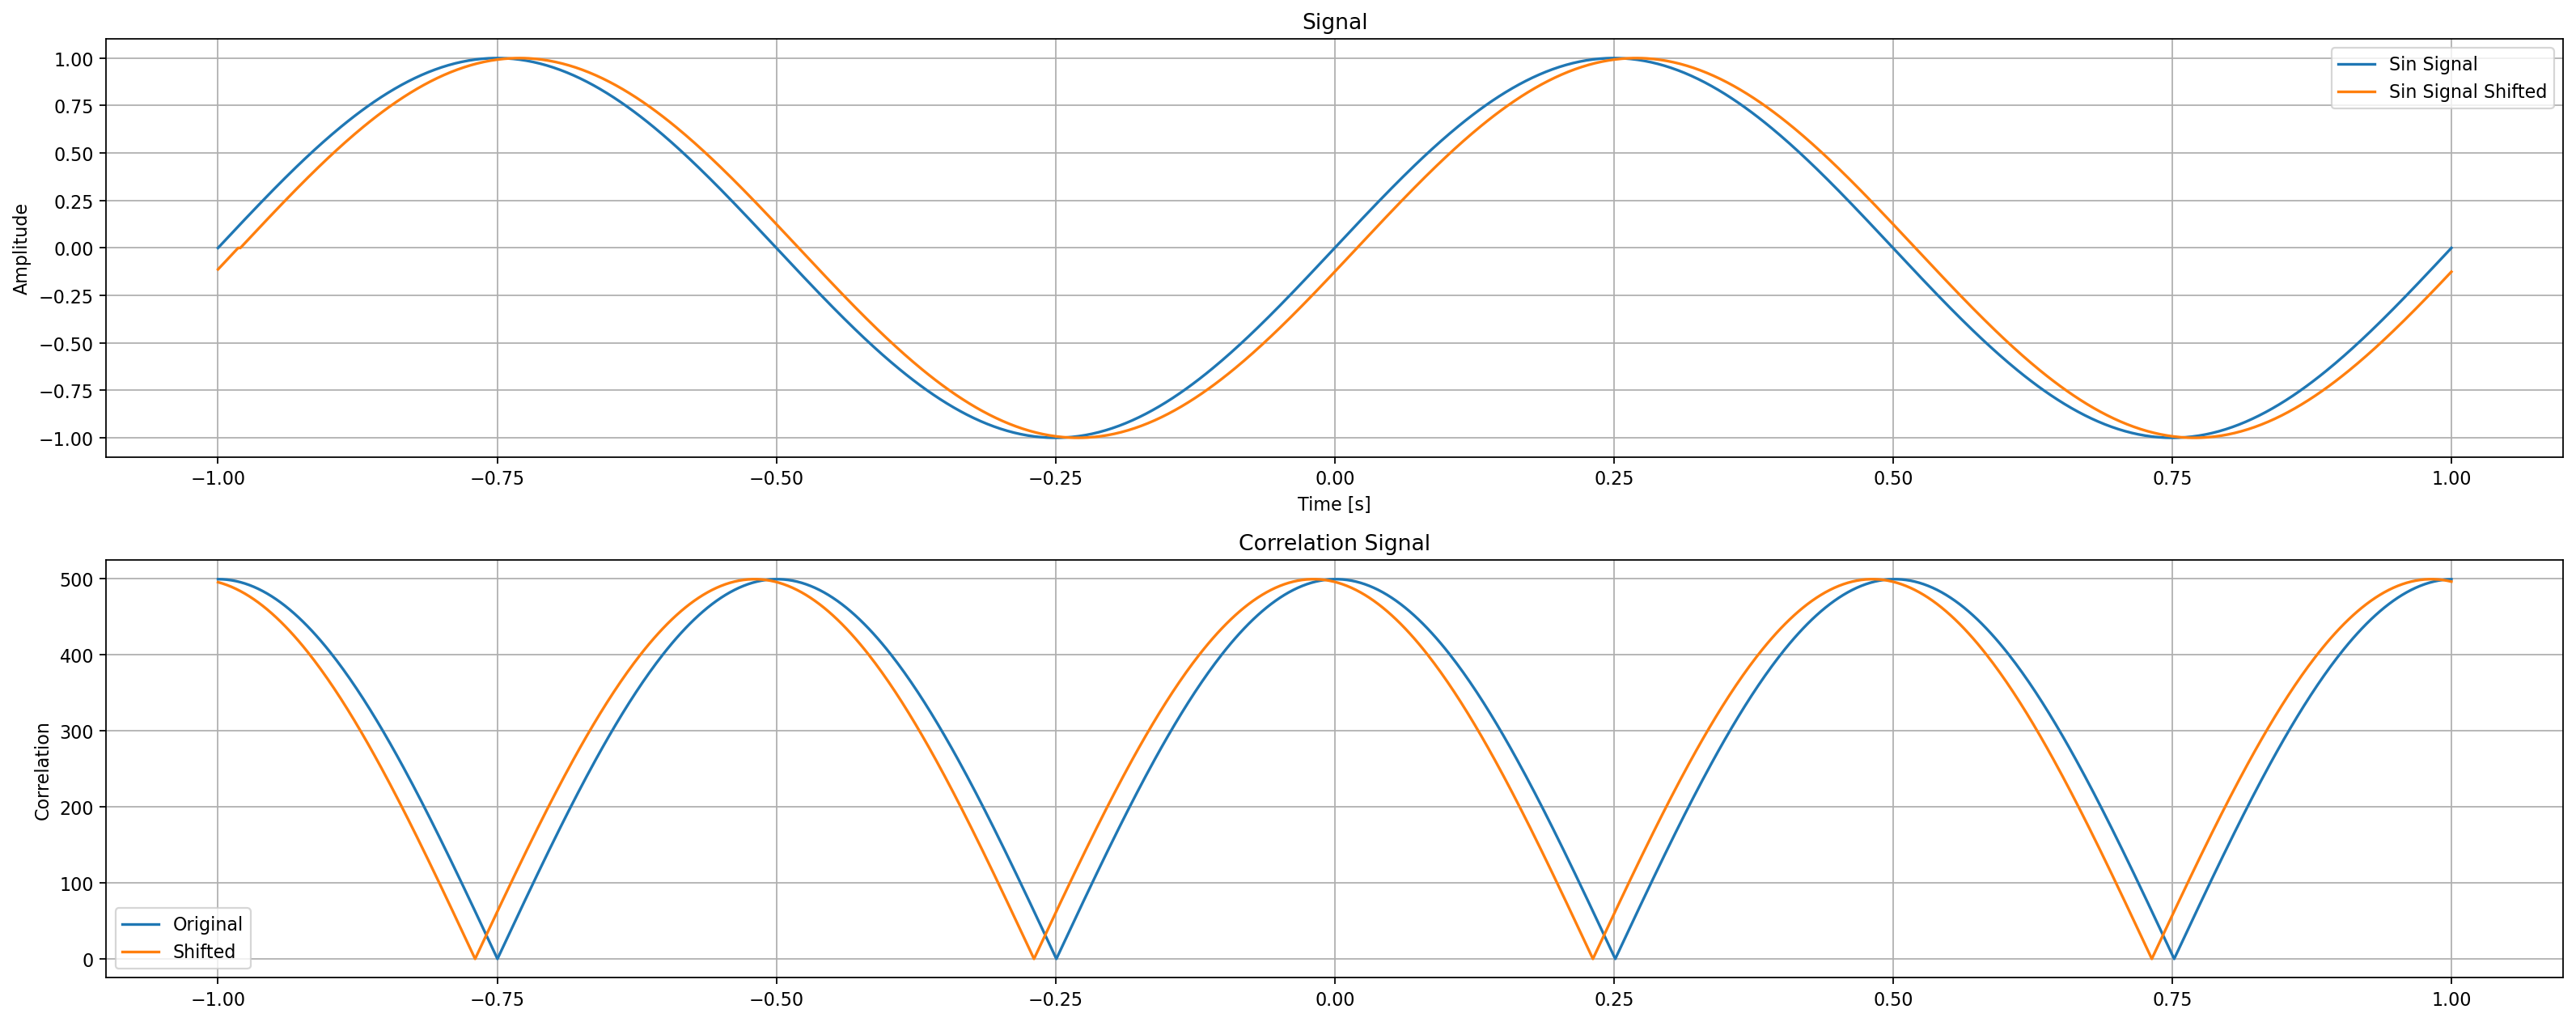

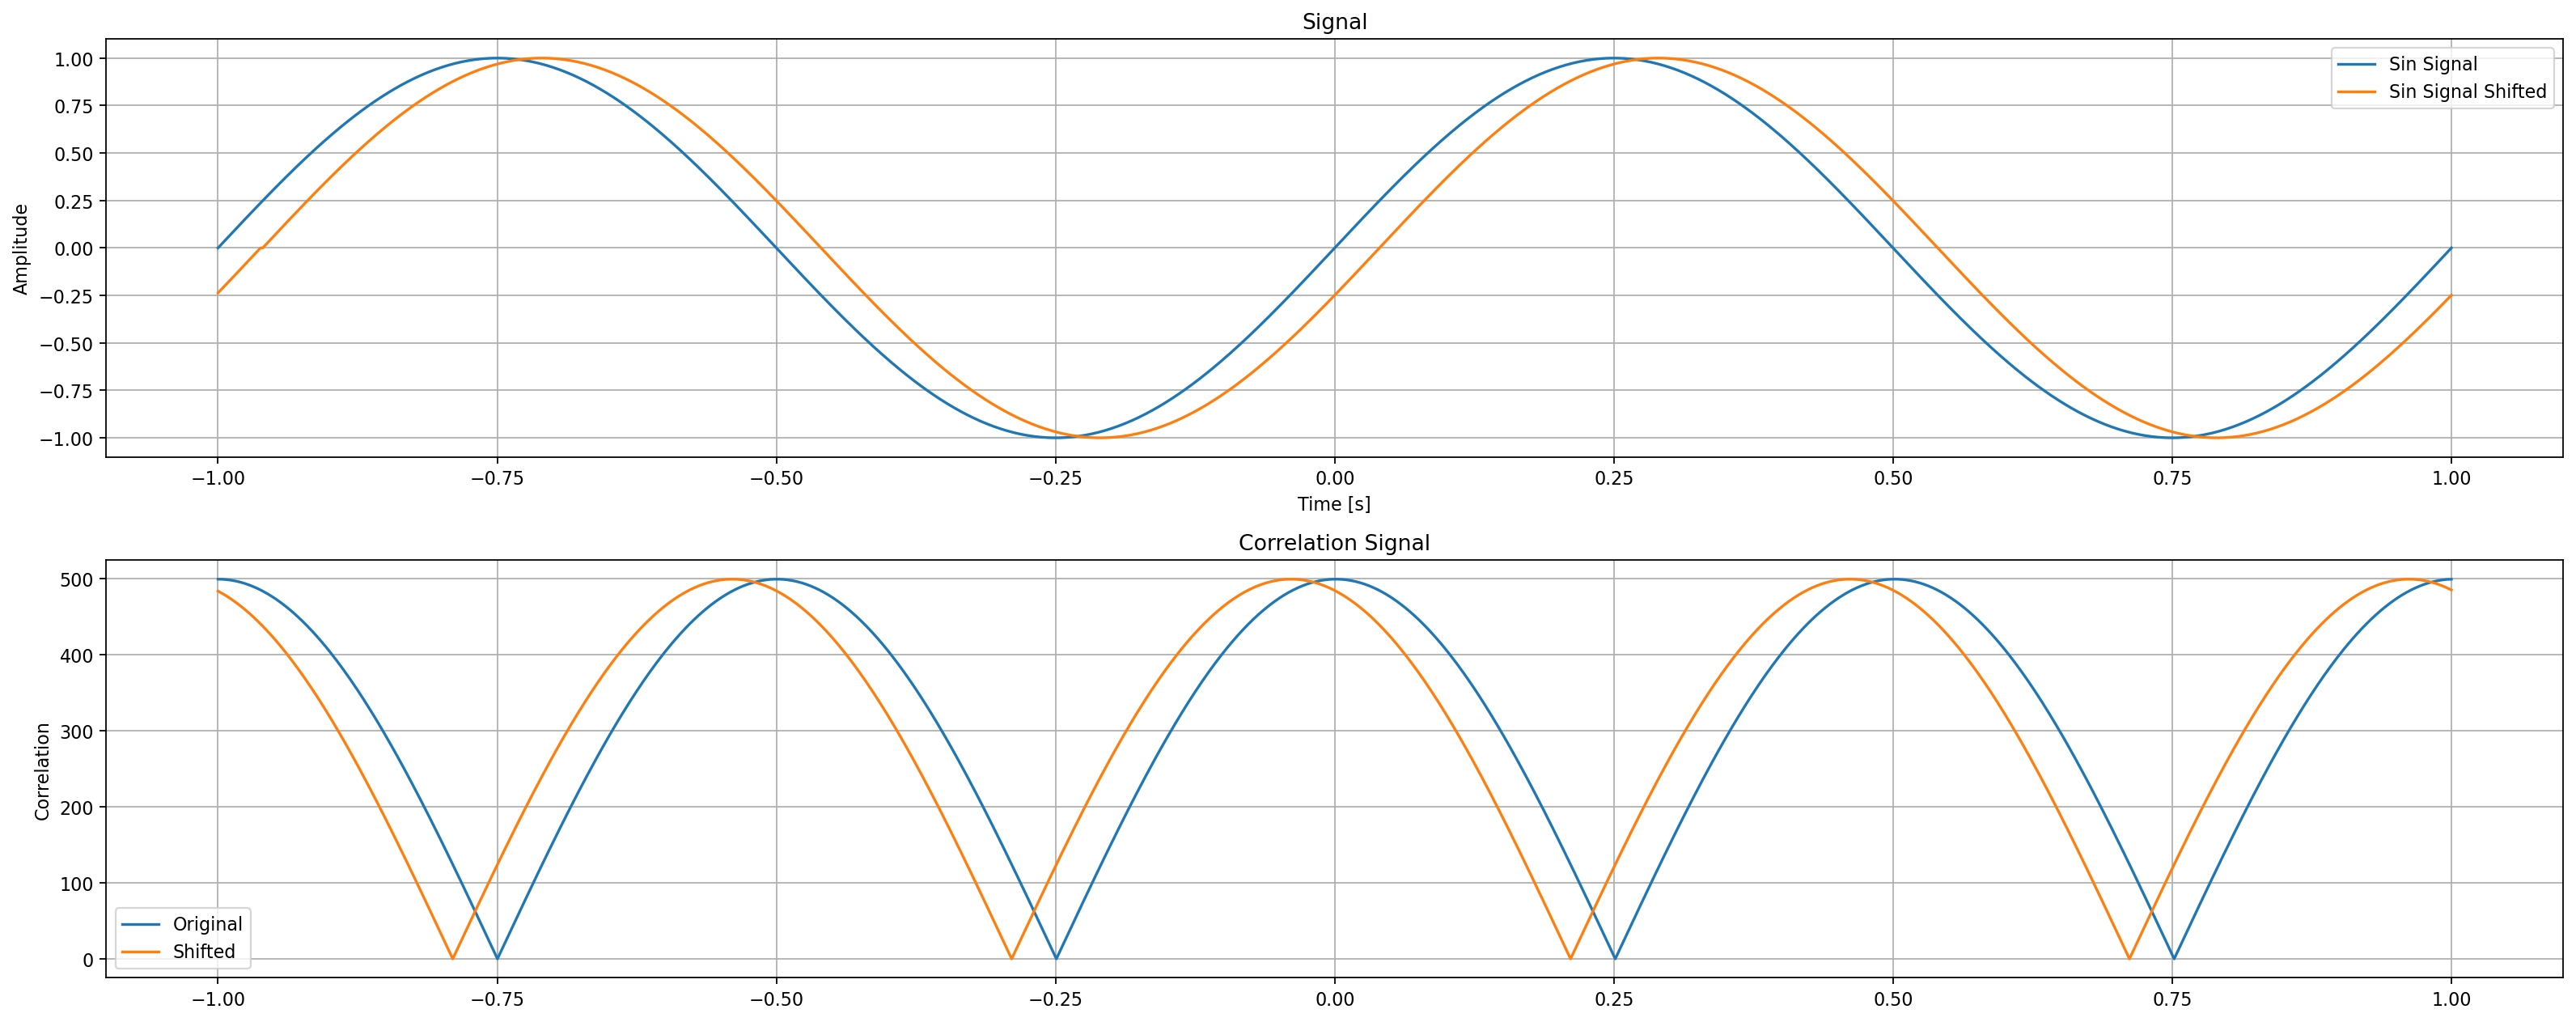

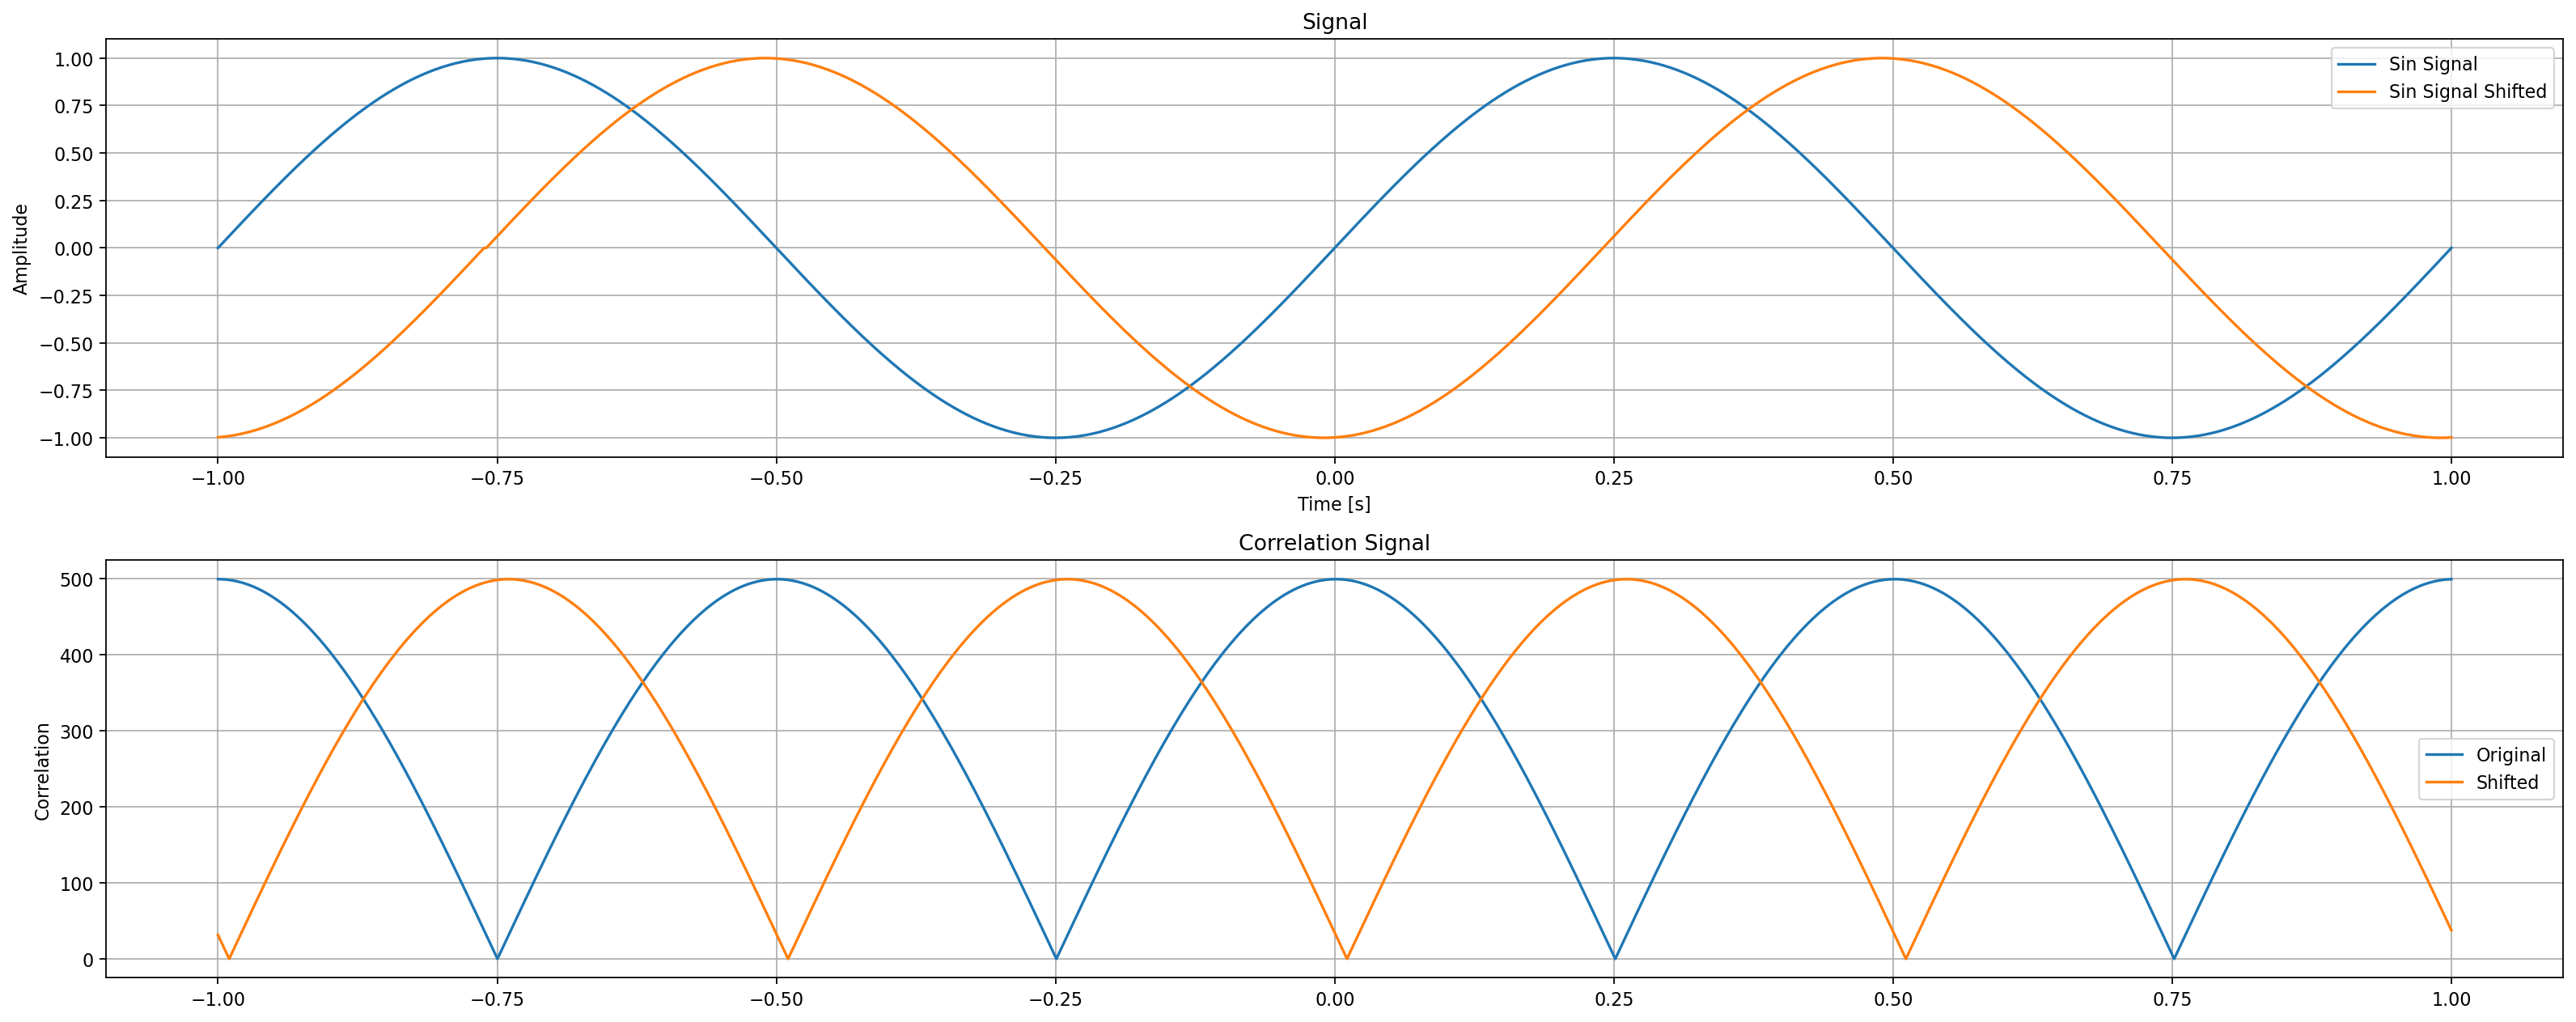

In [20]:
for shift_pixel in [10, 20, 120]:
    signal_sin = np.sin(2 * np.pi * t_sample)
    signal_sin_shift = np.roll(signal_sin.copy(), shift_pixel) # ずらす

    # plot
    plt.figure(figsize=(20, 8), facecolor='w', edgecolor='k', dpi=160)
    plt.subplot(2, 1, 1)
    plt.plot(t_sample, np.real(signal_sin), label='Sin Signal')
    plt.plot(t_sample, np.real(signal_sin_shift), label='Sin Signal Shifted')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid()
    plt.title('Signal')

    correlation_shift = impulse_response(signal_sin, signal_sin_shift)
    plt.subplot(2, 1, 2)
    plt.plot(t_sample, np.abs(correlation), label='Original')
    plt.plot(t_sample, np.abs(correlation_shift), label='Shifted')
    plt.xlabel('')
    plt.ylabel('Correlation')
    plt.grid()
    plt.title('Correlation Signal')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PATH_OUTPUT, f'correlation_signal_shift_{shift_pixel}.png'))
    plt.show();plt.clf();plt.close();